### import the libs

In [1]:
import numpy as np 
import pandas as pd 
from sklearn import linear_model
import matplotlib.pyplot as plt

### load the data

In [6]:
data = pd.read_csv('FuelConsumption.csv')

### making the mask for train data and test data

In [13]:
mask = np.random.rand(len(data)) < 0.8
train = data[mask]
test = data[~mask]

In [ ]:
print(f"""train: {round((len(train)/len(data))*100,2)}
test: {round((len(test)/len(data))*100,2)}""")

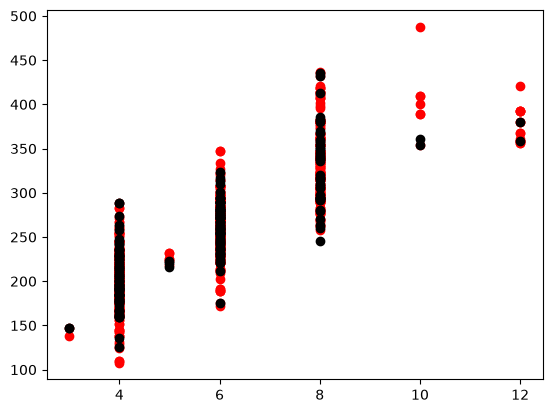

In [19]:
plt.scatter(train.CYLINDERS,train.CO2EMISSIONS,color='red')
plt.scatter(test.CYLINDERS, test.CO2EMISSIONS, color='black')

In [24]:
myAI = linear_model.LinearRegression()
train_x = np.asanyarray(train[['CYLINDERS']])
train_y = np.asanyarray(train[['CO2EMISSIONS']])

In [26]:
myAI.fit(train_x,train_y)
print(f"""m: {myAI.coef_}
b: {myAI.intercept_}""")

m: [[29.9667331]]
b: [82.3642386]


In [35]:
test_x = np.asanyarray(test[['CYLINDERS']])
test_y = np.asanyarray(test[['CO2EMISSIONS']])

test_y_out = myAI.predict(test_x)

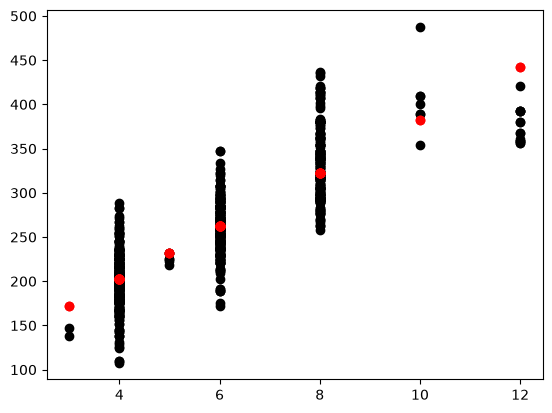

In [39]:
plt.scatter(train.CYLINDERS,train.CO2EMISSIONS,color='black')
plt.scatter(test.CYLINDERS,test_y_out,color='red')

In [33]:
question = 4
CO2 = myAI.coef_[0][0] * question + myAI.intercept_[0]

print(f"a car with this num of CYLINDERS: {question} can make this amount of CO2: {CO2}")

a car with this num of CYLINDERS: 4 can make this amount of CO2: 202.23117098726755


### extra stuff

In [40]:
print(f"""mean: {data.CO2EMISSIONS.mean()}
std: {data.CO2EMISSIONS.std()}""")

mean: 256.2286785379569
std: 63.372304442800065


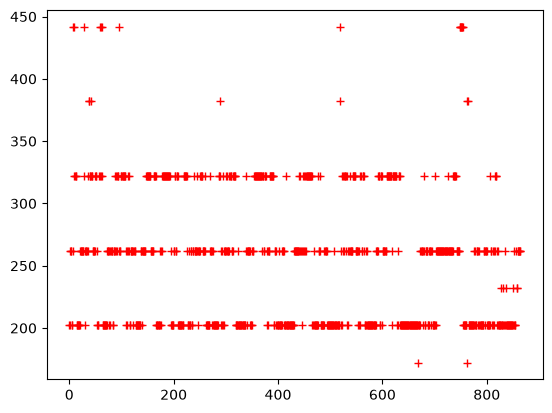

In [48]:
plt.plot(myAI.coef_[0][0] * train_x + myAI.intercept_[0],'r+')